# Разработка A/B-тестирования и анализ результатов
---

### *Описание*:   
Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя.    
### *Задача*:     
Рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

---

## Описание данных
Три таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23   

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14    

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02    

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


---

### 1. Работа с историческими данными (EDA)
---

#### 1.1. Загрузка исторических данных


In [1]:
# Импортируем библиотеки, при отсутствии — устанавливаем и импортируем
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Читаем данные из файла с сервера
df_session_history = pd.read_csv('секретная_информация/sessions_project_history.csv')

In [5]:
# Выводим первые 5 строк датафрейма
df_session_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными




In [6]:
# Для каждого пользователя рассчитаем количество сессий и запишем в новый столбец
df_session_history['session_count'] = df_session_history.groupby('user_id')['session_id'].transform('count')

# Выведем пользователя с наибольшим количеством сессий
top_users = df_session_history[df_session_history['session_count']==df_session_history['session_count'].max()]
top_user = top_users.iloc[0]['user_id']
display(df_session_history[df_session_history['user_id'] == top_user].reset_index())

,index,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,session_count
0,115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android,10
1,191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android,10
2,239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android,10
3,274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android,10
4,302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android,10
5,325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android,10
6,345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android,10
7,377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android,10
8,403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android,10
9,414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android,10


#### 1.3. Анализ числа регистраций


In [7]:
# На каждый день рассчитаем количество уникальных пользователей, а так же количество зарегистрированных. Для простоты наблюдений возьмем только первые сессии пользователей
df_daily_users = df_session_history.sort_values(['user_id', 'session_date', 'session_start_ts']).groupby(['user_id', 'session_date']).first().reset_index()
df_daily_users = df_daily_users.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'})


# Переименуем столбцы
df_daily_users = df_daily_users.rename(columns={'user_id': 'daily_active_users', 'registration_flag': 'count_registered_users'})

# Столбец session date приведем к формату "ДД.ММ"
df_daily_users.index = pd.to_datetime(df_daily_users.index).strftime('%d.%m')

# Рассчитаем долю зарегистрированных пользователей от всех активных пользователей в процентах
df_daily_users['share_registered'] = round(df_daily_users['count_registered_users'] / df_daily_users['daily_active_users'] * 100, 2)

display(df_daily_users)


,daily_active_users,count_registered_users,share_registered
session_date,,,
11.08,3919,169,4.31
12.08,6056,336,5.55
13.08,8489,464,5.47
14.08,10321,625,6.06
15.08,14065,840,5.97
16.08,12205,916,7.51
17.08,11200,833,7.44
18.08,10839,860,7.93
19.08,12118,831,6.86


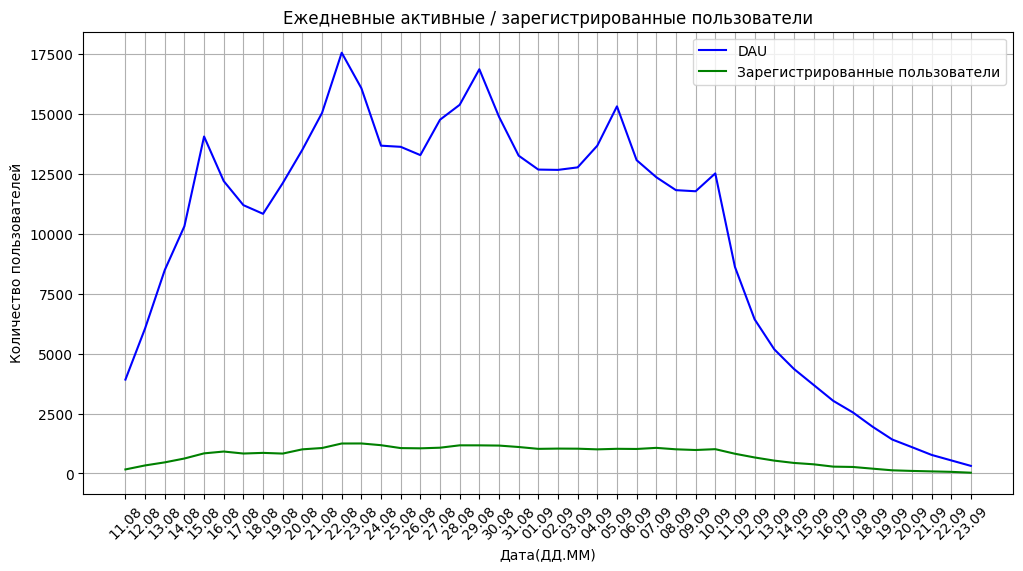

In [8]:
# Построим график ежедневных активных и зарегистрированных пользователей
plt.figure(figsize=(12, 6))
plt.plot(df_daily_users.index, df_daily_users['daily_active_users'], label='DAU', color='blue')
plt.plot(df_daily_users.index, df_daily_users['count_registered_users'], label='Зарегистрированные пользователи', color='green')
plt.title('Ежедневные активные / зарегистрированные пользователи')
plt.xlabel('Дата(ДД.ММ)')
plt.xticks(rotation=45)
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.show()

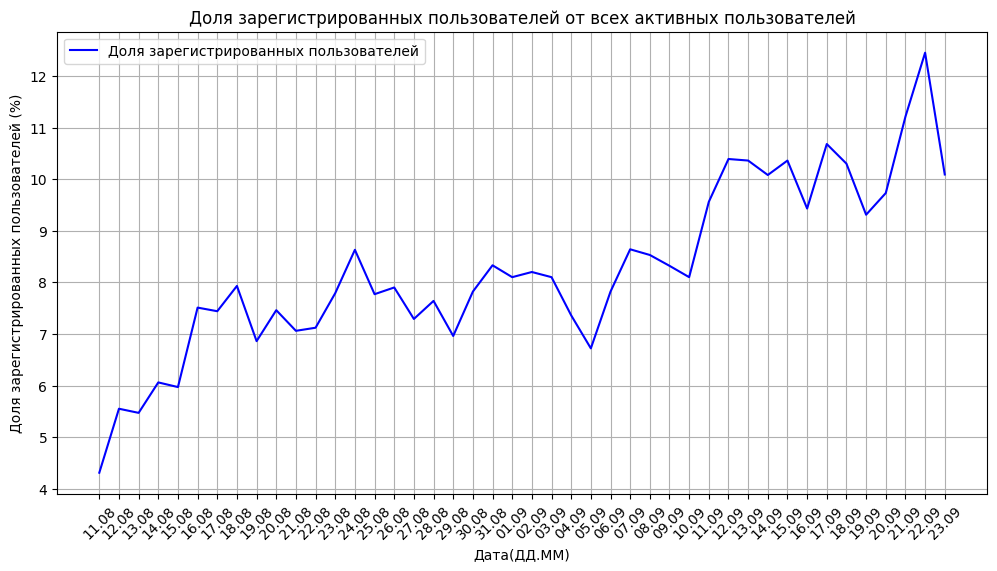

In [9]:

# Построим график доли зарегистрированных пользователей
plt.figure(figsize=(12, 6))
plt.plot(df_daily_users.index, df_daily_users['share_registered'], label='Доля зарегистрированных пользователей', color='blue')
plt.title('Доля зарегистрированных пользователей от всех активных пользователей')
plt.xlabel('Дата(ДД.ММ)')
plt.xticks(rotation=45)
plt.ylabel('Доля зарегистрированных пользователей (%)')
plt.legend()
plt.grid()
plt.show()

#### 1.4. Анализ числа просмотренных страниц


In [10]:
# Посчитаем количество сессий для каждого значения количества просомтренных страниц
df_count_sessions_per_page = df_session_history.groupby('page_counter').session_id.count().to_frame('count_sessions')
df_count_sessions_per_page.head()


,count_sessions
page_counter,
1,29160
2,105536
3,166690
4,105569
5,26288


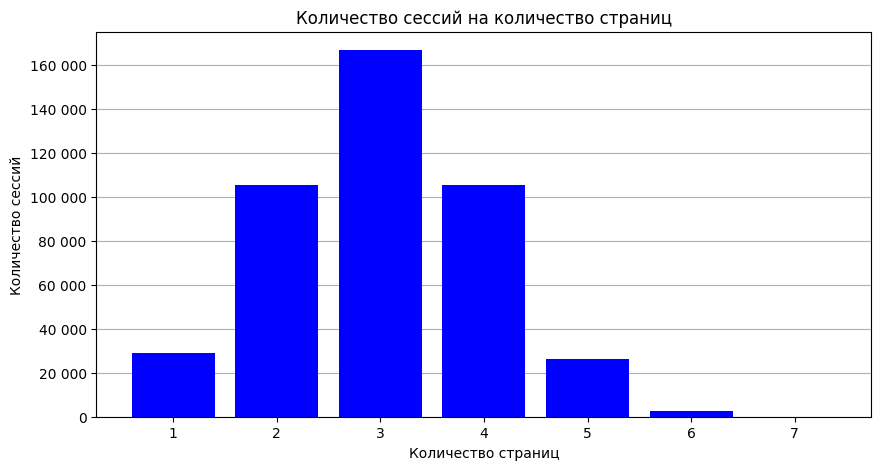

In [11]:
# Построим столбчатую диаграмму, отображающую количество сессий на количество просомтренных страниц
plt.figure(figsize = (10, 5))
plt.bar(df_count_sessions_per_page.index, df_count_sessions_per_page['count_sessions'], color = 'blue')

# Установим сетку позади, что бы не перекрывала столбцы
plt.gca().set_axisbelow(True)

# Отформатируем разряды чисел для красивого отображения
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:,.0f}'.replace(',', ' '))

# Основные настройки графика
plt.title('Количество сессий на количество страниц')
plt.xlabel('Количество страниц')
plt.ylabel('Количество сессий')
plt.grid(axis = 'y')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

In [12]:
# добавим новый столбец, заполнив его значениями 1, если количество просомтренных страниц было равно или больше 4, и 0, если нет
df_session_history['good_session'] = (df_session_history['page_counter'] >= 4).astype(int)
df_session_history.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,session_count,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,6,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,2,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,5,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,4,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,2,0
5,835DD33FC86B3584,3AC48B25BA586DB3,2025-08-15,2025-08-15 18:03:05,2025-08-15,1,0,3,MENA,Android,3,0
6,AE22C619172A9E28,F1A345355A8981FD,2025-08-15,2025-08-15 23:20:57,2025-08-15,1,0,3,MENA,Android,4,0
7,2D63C6E7B6D5691B,8EC5B17CA1ED5E10,2025-08-15,2025-08-15 14:45:02,2025-08-15,1,0,5,MENA,PC,4,1
8,4FFA441542A50124,E99DF62E41ECAB10,2025-08-15,2025-08-15 18:28:23,2025-08-15,1,0,4,CIS,iPhone,2,1
9,61DCA6C89DA4288D,3F870A71E087CFE6,2025-08-15,2025-08-15 18:58:52,2025-08-15,1,0,5,CIS,Android,4,1


In [13]:
# Рассчитаем долю хороших сессий от общего числа сессий, сгруппировав по дням
df_good_session_share = round(
    df_session_history.groupby('session_date').good_session.sum()
    / df_session_history.groupby('session_date').session_id.count()
    * 100, 2).to_frame('share')

# Столбец session date приведем к формату "ДД.ММ" для красивого графика
df_good_session_share.index = pd.to_datetime(df_good_session_share.index).strftime('%d.%m')

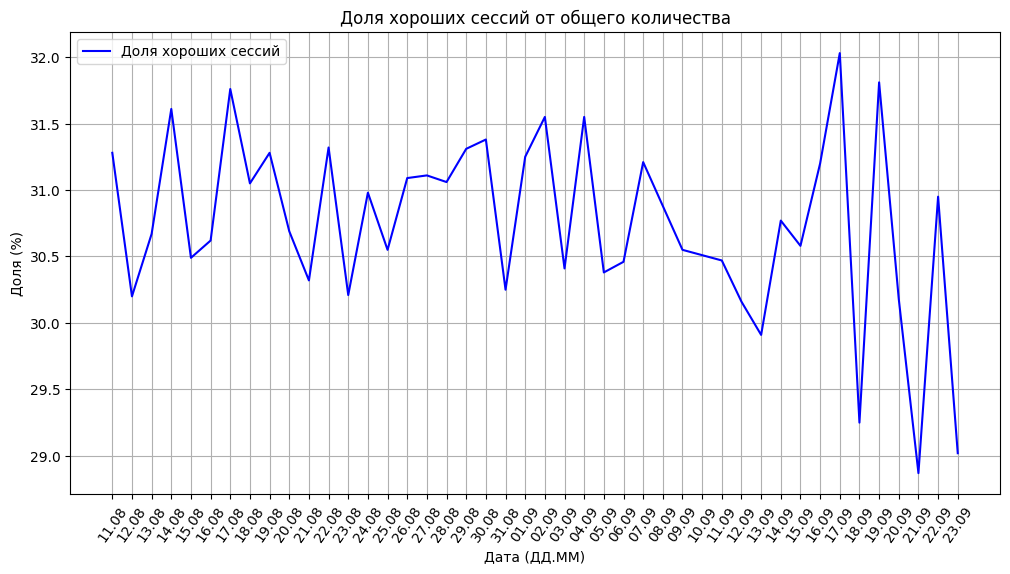

In [14]:
# Рисуем линейный график
plt.figure(figsize=(12, 6))
plt.plot(df_good_session_share.index, df_good_session_share.share,label = 'Доля хороших сессий', color='blue')
plt.title('Доля хороших сессий от общего количества')
plt.ylabel('Доля (%)')
plt.xlabel('Дата (ДД.ММ)')
plt.xticks(rotation = 55)
plt.legend()
plt.grid()
plt.show()

---

### 2. Подготовка к тесту


---

#### 2.1 Формулировка нулевой и альтернативной гипотез

Целевая метрика - доля успешных сессий, т.е. сессии, в течении которых пользователь просматривал 4 и более страниц. Т.к. как новый алгоритм должен показывать более интересный контент,    
то пользователи должны просматривать больше страниц за сессию и количество успешных сессий возрастет.   
Нулевая гипотеза (Н0): Доля успешных сессий не изменится.  
*Н0: x̄1 = x̄2*     
Альтернативная гипотеза (Н1): Доля успешных сессий увеличится.    
*Н1: x̄2 > x̄1*     

#### 2.2. Расчёт размера выборки

In [18]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

In [19]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = df_session_history.groupby('session_date').user_id.nunique().reset_index()
avg_daily_users = ceil(avg_daily_users.user_id.mean())
display(avg_daily_users)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

9908

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9908 пользователей в день составит 9 дней


---
### 3. Мониторинг А/В-теста
---

#### 3.1. Проверка распределения пользователей

In [ ]:
# Читаем данные из файла с сервера
df_session_test_part = pd.read_csv('секретная_информация/sessions_project_test_part.csv')
df_session_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [23]:
# Считаем количество уникальных пользователей для каждой группы в день
df_test_part_dau = df_session_test_part.groupby('test_group').user_id.nunique().to_frame('dau')

# Считаем разницу между двумя группами в процентах
diff = round(abs(((df_test_part_dau['dau'][0] - df_test_part_dau['dau'][1]) / df_test_part_dau['dau'][1]) * 100), 2)

print(f'''Количество уникальных пользователей за один день, для группы "А" составило {df_test_part_dau['dau'][0]}
Для группы "В": {df_test_part_dau['dau'][1]}
Разница между группами  в процентном соотношении составляет {diff}%
''')

Количество уникальных пользователей за один день, для группы "А" составило 1477
Для группы "В": 1466
Разница между группами  в процентном соотношении составляет 0.75%



/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_84273/1220343202.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diff = round(abs(((df_test_part_dau['dau'][0] - df_test_part_dau['dau'][1]) / df_test_part_dau['dau'][1]) * 100), 2)
/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_84273/1220343202.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'''Количество уникальных пользователей за один день, для группы "А" составило {df_test_part_dau['dau'][0]}
/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_84273/1220343202.py:8: FutureWarning: Series.__getitem__ treating keys as posi

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_84273/2436387856.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(df_test_part_dau.index[0], df_test_part_dau['dau'][0], label='Группа "А"', color='blue', width=1.2)
/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_84273/2436387856.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(df_test_part_dau.index[1], df_test_part_dau['dau'][1], label='Группа "B"', color='green', width=1.2)


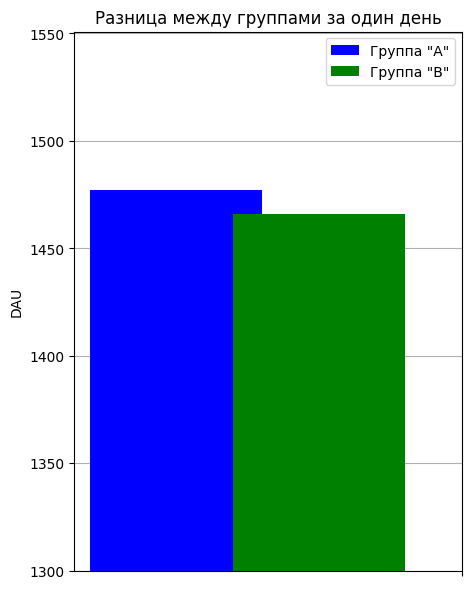

In [24]:
# Нарисуем столбчатую диаграмму для каждой группы
plt.figure(figsize=(5, 7))

# Для наглядности сделаем пересечение столбцов и покрасим их в разный цвет
plt.bar(df_test_part_dau.index[0], df_test_part_dau['dau'][0], label='Группа "А"', color='blue', width=1.2)
plt.bar(df_test_part_dau.index[1], df_test_part_dau['dau'][1], label='Группа "B"', color='green', width=1.2)

# Спрячем сетку за столбцами
plt.gca().set_axisbelow(True)

# Что бы график был более наглядным, установим масштаб оси Y от 1300
plt.gca().set_ylim(bottom=1300)

plt.title('Разница между группами за один день')
plt.ylabel('DAU')
plt.xlabel('')
plt.xticks('')
plt.legend()
plt.grid(axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей

In [25]:
# Сохраним список пользователей из двух групп, для каждой своя серия
a = df_session_test_part[df_session_test_part['test_group'] == 'A']['user_id']
b = df_session_test_part[df_session_test_part['test_group'] == 'B']['user_id']

# Првоерим пересечения
intersection = list(set(a) & set(b))

if len(intersection) > 0:
    print(f'Пересечения: {intersection}')
else:
    print('Пересечений нет')

Пересечений нет


#### 3.3. Равномерность разделения пользователей по устройствам


In [26]:
# Посчитаем количество пользователей в группах по устройствам, выведем на экран
df_session_test_part_device = df_session_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index(name='dau')
df_session_test_part_device['share'] = round(df_session_test_part_device.dau / df_session_test_part_device.groupby('test_group').dau.transform('sum') * 100, 2)
display(df_session_test_part_device)

,test_group,device,dau,share
0,A,Android,656,44.41
1,A,Mac,156,10.56
2,A,PC,369,24.98
3,A,iPhone,296,20.04
4,B,Android,668,45.57
5,B,Mac,148,10.10
6,B,PC,381,25.99
7,B,iPhone,269,18.35


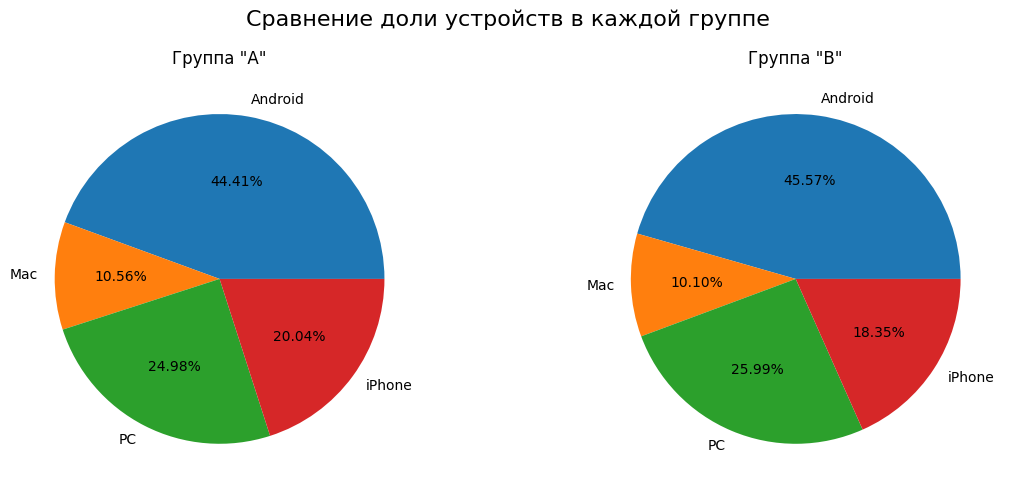

In [27]:
# Сохраним выборки из таблицы для компактного кода
a_device = df_session_test_part_device[df_session_test_part_device.test_group=='A']
b_device = df_session_test_part_device[df_session_test_part_device.test_group=='B']

# Нарисуем круговые диаграммы
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axs[0].pie(a_device.share, labels=a_device.device, autopct='%1.2f%%')
axs[0].set_title('Группа "А"')

axs[1].pie(b_device.share, labels=b_device.device, autopct='%1.2f%%')
axs[1].set_title('Группа "В"')


plt.suptitle('Сравнение доли устройств в каждой группе', fontsize = 16)
plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам


In [28]:
# Расчитаем долю пользователей по регионам в группах
df_session_test_part_region = df_session_test_part.groupby(['test_group', 'region']).user_id.nunique().reset_index(name='dau')
df_session_test_part_region['share'] = round(df_session_test_part_region.dau / df_session_test_part_region.groupby('test_group').dau.transform('sum') * 100, 2)
display(df_session_test_part_region)


,test_group,region,dau,share
0,A,CIS,644,43.60
1,A,EU,224,15.17
2,A,MENA,609,41.23
3,B,CIS,645,44.00
4,B,EU,217,14.80
5,B,MENA,604,41.20


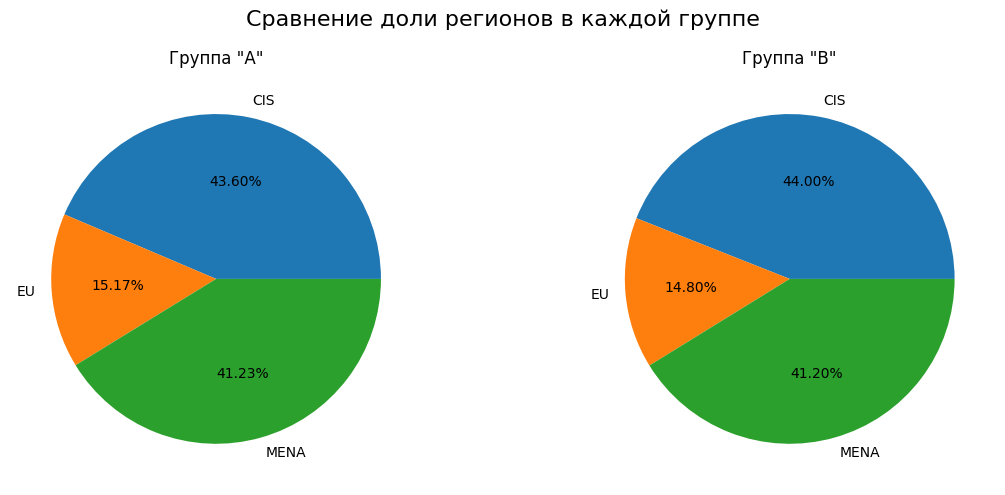

In [29]:
# Сохраним выборки из таблицы для компактного кода
a_region = df_session_test_part_region[df_session_test_part_region.test_group=='A']
b_region = df_session_test_part_region[df_session_test_part_region.test_group=='B']

# Нарисуем круговые диаграммы
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axs[0].pie(a_region.share, labels=a_region.region, autopct='%1.2f%%')
axs[0].set_title('Группа "А"')

axs[1].pie(b_region.share, labels=b_region.region, autopct='%1.2f%%')
axs[1].set_title('Группа "В"')


plt.suptitle('Сравнение доли регионов в каждой группе', fontsize = 16)
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

По результатам проведенных рассчетов и визуализаций можно сделать следующие выводы:    
- Различия в группах по количеству уникальных пользователей не являются статистически значимыми, составляют всего 11 ед., что равно 0,75% (между группами).   
- Выборки являются независимыми, пересечений пользователей не обнаружено.   
- Исходя из данных распределений пользователей тестовой и контрольной групп, по устройствам и регионам равномерное распределение. Отличия по устройствам составляют менее 2%, отличия по регионам менее 0,5%.   

A/B тест проходит корректно, нарушений не выявлено.

---
### 4. Проверка результатов A/B-теста
---

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [ ]:
# Загружаем данные с сервера
df_session_test = pd.read_csv('секретная_информация/sessions_project_test.csv')
df_session_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [33]:
# Создадим новое поле good_session, заполним его 1, если пользователь за одну сессию просомтрел 4 и более страницы, и 0, если менее
df_session_test['good_session'] = (df_session_test.page_counter >= 4).astype(int)

#### 4.2. Проверка корректности результатов теста

In [34]:
# Импортируем билиотеку scipy
import scipy.stats as stats

In [35]:
# Рассчитаем количество уникальных сессий, используя группировку по дням, для обеих тестовых групп
df_session_test_count_sessions = df_session_test.groupby(['session_date', 'test_group']).session_id.nunique().unstack(fill_value=0).reset_index()

In [36]:
# Проверим количество наблюдений, для выбора статистического теста
print('Количество наблюдений: ', len(df_session_test_count_sessions))

Количество наблюдений:  20


In [37]:
# Т.к. количество наблюдений для каждой группы <30 (20), будем использовать тест Манна - Уитни
test_mw = stats.mannwhitneyu(
    df_session_test_count_sessions['A'],
    df_session_test_count_sessions['B'],
    alternative='two-sided'
)
print('p-value: ', test_mw.pvalue)


p-value:  0.8817307917391243


Исходя из полученного значения p-value, можно сделать выводы, что распределения среднего количество уникальных сессий для групп "А" и "В" равны

#### 4.3. Сравнение доли успешных сессий

In [38]:
# Рассчитаем долю успешных сессий для каждой группы
good_session = df_session_test.groupby('test_group')['good_session'].mean().to_frame('share')

# Рассчитаем разницу целевой метрики между группами
good_session_diff = round(abs((good_session.share['A'] - good_session.share['B']) * 100), 2)
print(f'Разница целевой метрики между группами составила: {good_session_diff}')

Разница целевой метрики между группами составила: 1.06


#### 4.4. Насколько статистически значимо изменение ключевой метрики

In [39]:
# Для выбора статистического теста необходимо узнать количество наблюдений
print('Количество наблюдений: ', len(df_session_test[df_session_test.test_group == 'A']))

Количество наблюдений:  49551


In [40]:
# Используем t-тест Уэлча
stat_wtt, p_value_wtt = stats.ttest_ind(
    df_session_test[df_session_test['test_group']=='A'].good_session,
    df_session_test[df_session_test['test_group']=='B'].good_session,
    equal_var=False,
    alternative='less'
)
alpha = 0.05

if p_value_wtt > alpha:
    print(f'P-value Уэлча = {round(p_value_wtt, 5)}\nНулевая гипотеза подтверждена!')
else:
    print(f'p-value Уэлча = {round(p_value_wtt, 5)}\nНулевая гипотеза не подтверждена!')

p-value Уэлча = 0.00016
Нулевая гипотеза не подтверждена!


#### 4.5. Вывод по результатам A/B-эксперимента

##### Вывод о проделанной работе:
- В эксперименте были использованы данные по 30.5 тыс. уникальных пользователей. Количество наблюдений для каждой группы составило 49551, исходя из расчетных 41040.       
Длительность эксперимента согласно данных составляет 20 дней, расчетных 14. Можно сказать, что эксперимент выполнен полностью.    
- Так как по результатам t-теста Уэлча, значение p-value равно 0,00016, мы можем подтвердить гипотезу о том, что метрика успешных сессий для тестовой группы "В" больше, чем в контрольной группе "А".    
Исходя из всех полученных результатов, можно сделать вывод, что введение нового алгоритма целесобразно.